# Imports and Defaults

In [1]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
sns.set_style("whitegrid")

# Data

In [ ]:
# data dictionary of sampling steps and perplexity across various sampling strategies
# NFE keys are actual mean NFEs from sample_eval runs (not paper targets).
# Integer-k strategies below are from a prior run (stale; re-run pending once
# sample_eval.sh integer-k loop is uncommented and re-run).
# AR/Uniform baselines below are also stale (AG News numbers, not OWT) — update
# once OWT baseline runs are complete.

left_to_right = {
    128: 973.14,
    # 256: N/A,
    # 512: N/A,
    1024: 18.75
}

greedy = {
    128: 873.18,
    256: 636.04,
    512: 176.62,
    1024: 18.23,
}

probablity_margin = {
    128: 876.11,
    256: 497.09,
    512: 120.38,
    1024: 21.72
}

# Confirmed 2026-05-01: k=(0.045, 0.08, 0.16, 1.0) -> NFE=(135, 270, 524, 921).
# All within 5.6% of targets {128, 256, 512, 1024}. NFE=921 is the
# generation-mode ceiling (BOS token reduces maskable positions to 1023).
confidence_threshold = {
    135: 754.88,
    270: 520.00,
    524: 190.86,
    921: 16.75,
}

# autoregressive_perplexity = N/A (stale AG News value below — replace with OWT)
uniform_perplexity = 36.31  # stale — replace with OWT uniform baseline

In [8]:
# Consolidating data into a list of dictionaries for long-form DataFrame
data_list = []

for steps, perp in left_to_right.items():
    data_list.append({'Sampling Steps': steps, 'Perplexity': perp, 'Strategy': 'Left-to-Right'})

for steps, perp in greedy.items():
    data_list.append({'Sampling Steps': steps, 'Perplexity': perp, 'Strategy': 'Greedy'})

for steps, perp in probablity_margin.items():
    data_list.append({'Sampling Steps': steps, 'Perplexity': perp, 'Strategy': 'Probability Margin'})

for steps, perp in confidence_threshold.items():
    data_list.append({'Sampling Steps': steps, 'Perplexity': perp, 'Strategy': 'Confidence Threshold'})

# Create DataFrame
df = pd.DataFrame(data_list)
df.head()

,Sampling Steps,Perplexity,Strategy
0,128,973.14,Left-to-Right
1,1024,18.75,Left-to-Right
2,128,873.18,Greedy
3,256,636.04,Greedy
4,512,176.62,Greedy


# Plotting

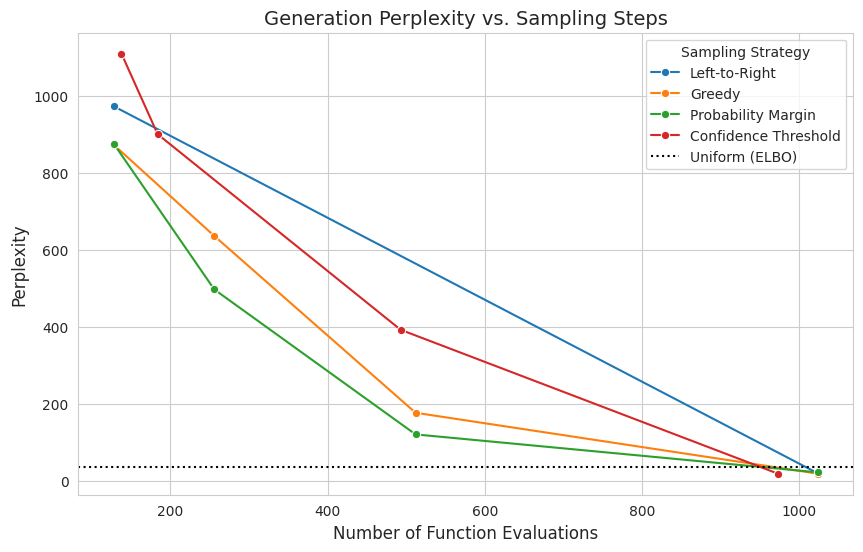

In [10]:
plt.figure(figsize=(10, 6))
plot = sns.lineplot(
    data=df, 
    x='Sampling Steps', 
    y='Perplexity', 
    hue='Strategy', 
    marker='o', 
)

# Add horizontal baselines
# ar_line = plt.axhline(y=autoregressive_perplexity, color='gray', linestyle='--', linewidth=1.5, label='Autoregressive')
uniform_line = plt.axhline(y=uniform_perplexity, color='black', linestyle=':', linewidth=1.5, label='Uniform (ELBO)')

# Refine labels
plt.xlabel('Number of Function Evaluations', fontsize=12)
plt.ylabel('Perplexity', fontsize=12)

# Add title
plt.title('Generation Perplexity vs. Sampling Steps', fontsize=14)

# Update legend to include baselines
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles=handles, 
           title='Sampling Strategy', 
           frameon=True)

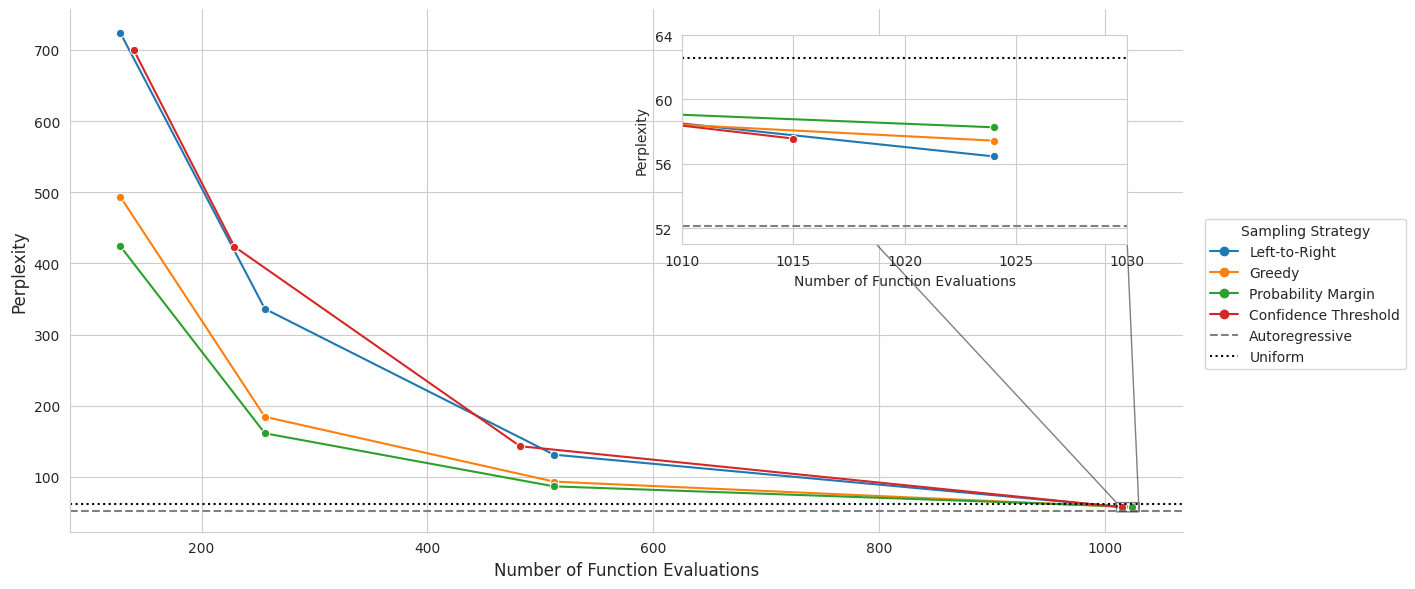

In [20]:
fig = sns.relplot(
    data=df, 
    kind='line',
    x='Sampling Steps', 
    y='Perplexity', 
    hue='Strategy', 
    marker='o',
    height=6,
    aspect=1.67,
)

# Get the underlying axes
ax = fig.axes[0, 0]

# Get existing handles/labels from the seaborn plot
handles, labels = ax.get_legend_handles_labels()

# Remove the default legend
if fig._legend:
    fig._legend.remove()

# Add horizontal baselines
ar_line = ax.axhline(y=52.11, color='gray', linestyle='--', linewidth=1.5, label='Autoregressive')
uniform_line = ax.axhline(y=62.58, color='black', linestyle=':', linewidth=1.5, label='Uniform')

# Labels
ax.set_xlabel('Number of Function Evaluations', fontsize=12)
ax.set_ylabel('Perplexity', fontsize=12)

# Create combined legend (strategies + baselines)
fig.figure.legend(
    handles=handles + [ar_line, uniform_line], 
    labels=labels + ['Autoregressive', 'Uniform'],
    title='Sampling Strategy', 
    frameon=True, 
    loc='center left',
    bbox_to_anchor=(1, 0.5)
)

# Inset zoom - moved to upper right
x1, x2, y1, y2 = 1010, 1030, 51, 64
axins = ax.inset_axes(
    [0.55, 0.55, 0.4, 0.4],  # Upper right position
    xlim=(x1, x2), ylim=(y1, y2)
)

# Replot data in inset
sns.lineplot(
    data=df, 
    x='Sampling Steps', 
    y='Perplexity', 
    hue='Strategy', 
    marker='o',
    ax=axins,
    legend=False
)
axins.axhline(y=52.11, color='gray', linestyle='--', linewidth=1.5)
axins.axhline(y=62.58, color='black', linestyle=':', linewidth=1.5)

# Rename axis labels for inset
axins.set_xlabel('Number of Function Evaluations', fontsize=10)
axins.set_ylabel('Perplexity', fontsize=10)

# Less frequent ticks for clarity
axins.xaxis.set_major_locator(plt.MaxNLocator(4))
axins.yaxis.set_major_locator(plt.MaxNLocator(4))

# Draw connection lines
ax.indicate_inset_zoom(axins, edgecolor="black")

plt.tight_layout()
plt.show()